In [1]:
from csv import DictReader

with open('data/combustdb_master.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    rows = [r for r in reader]
csv_file.close()

compounds = [r for r in rows if r['properties.cetane_number.value'] != '-']
print(len(compounds))

408


In [2]:
from alvadescpy import smiles_to_descriptors

descriptors = [smiles_to_descriptors(c['canonical_smiles']) for c in compounds]

In [3]:
import pandas as pd
import numpy as np

df = pd.DataFrame(descriptors)

X = df.values
for i in range(len(X)):
    for j in range(len(X[i])):
        if X[i][j] == 'na':
            X[i][j] = 0.0
X = X.astype('float32')

y = np.array([[float(c['properties.cetane_number.value'])] for c in compounds], dtype='float32')

print(X.shape, y.shape)

(408, 5305) (408, 1)


In [4]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaler.fit(X)

X_norm = scaler.transform(X)
print(X_norm.shape)

(408, 5305)


In [5]:
from sklearn.decomposition import PCA

pca = PCA(svd_solver='full', random_state=0)
pca.fit(X_norm)
X_pca = pca.transform(X_norm)
print(X_pca.shape)

(408, 408)


In [6]:
from sklearn.neighbors import LocalOutlierFactor

clf = LocalOutlierFactor(n_neighbors=5, metric='euclidean', leaf_size=30, algorithm='brute')
clf.fit(X_pca)
neg_outlier_factors = clf.negative_outlier_factor_
print(len(neg_outlier_factors))

408


In [7]:
with open('pred_results.csv', 'r') as csv_file:
    reader = DictReader(csv_file)
    results = [r for r in reader]
csv_file.close()

In [8]:
pred = [float(r['pred']) for r in results]
actual = [float(r['actual']) for r in results]

abs_err = [abs(pred[i] - actual[i]) for i in range(len(pred))]
err = [pred[i] - actual[i] for i in range(len(pred))]

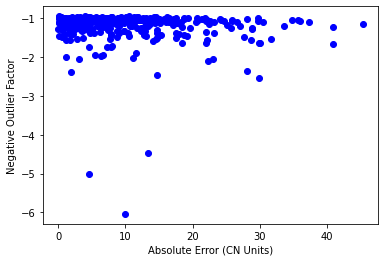

In [9]:
from matplotlib import pyplot as plt

err_to_plot = []
of_to_plot = []
for i in range(len(abs_err)):
    if abs_err[i] < 60 and neg_outlier_factors[i] > -8:
        err_to_plot.append(abs_err[i])
        of_to_plot.append(neg_outlier_factors[i])

plt.scatter(err_to_plot, of_to_plot, color='blue')
plt.xlabel('Absolute Error (CN Units)')
plt.ylabel('Negative Outlier Factor')
plt.show()

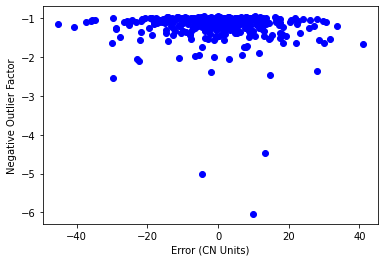

In [10]:
plt.clf()
err_to_plot = []
of_to_plot = []
for i in range(len(err)):
    if abs(err[i]) < 60 and neg_outlier_factors[i] > -8:
        err_to_plot.append(err[i])
        of_to_plot.append(neg_outlier_factors[i])

plt.scatter(err_to_plot, of_to_plot, color='blue')
plt.xlabel('Error (CN Units)')
plt.ylabel('Negative Outlier Factor')
plt.show()